This notebook explores the OECD datasets that will be used as training data for the models: CPI index, RGDP growth, unemployment rate. The data will be pre-processed by putting it into pandas dataframes with a shape of (countries, timesteps)

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [165]:
cpi_index = pd.read_csv('..\\data\\raw_data\\CPI_index.csv')
rgdp = pd.read_csv('..\\data\\raw_data\\RGDP_growth_rate.csv')
unemployment = pd.read_csv('..\\data\\raw_data\\unemployment_rate.csv')

In [166]:
cpi_index.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA',
       'Reference area', 'FREQ', 'Frequency of observation', 'METHODOLOGY',
       'Methodology', 'MEASURE', 'Measure', 'UNIT_MEASURE', 'Unit of measure',
       'EXPENDITURE', 'Expenditure', 'ADJUSTMENT', 'Adjustment',
       'TRANSFORMATION', 'Transformation', 'TIME_PERIOD', 'Time period',
       'OBS_VALUE', 'Observation value', 'OBS_STATUS', 'Observation status',
       'UNIT_MULT', 'Unit multiplier', 'BASE_PER', 'Base period', 'DURABILITY',
       'Durability', 'DECIMALS', 'Decimals'],
      dtype='str')

All the columns in the original dataframe are not needed, as OECD includes lots of additional data for every sample, which is predominantly not required. Only the country, time stamp, and the value itself are needed

In [167]:
cpi_index = cpi_index[['Reference area', 'TIME_PERIOD', 'OBS_VALUE']]
rgdp = rgdp[['Reference area', 'TIME_PERIOD', 'OBS_VALUE']]
unemployment = unemployment[['Reference area', 'TIME_PERIOD', 'OBS_VALUE']]
cpi_index.head()

,Reference area,TIME_PERIOD,OBS_VALUE
0,United States,2026-Q2,140.931500
1,Indonesia,2026-Q2,137.166300
2,United Kingdom,2026-Q2,142.100000
3,South Africa,1980-Q1,4.698460
4,South Africa,1980-Q2,4.852004


Due to unconsistent availability of data, for training and in-sample evaluation, only the values from 1993 to 2019 (incl) will be used for the following countries: Australia, Austria, Belgium, Canada, Denmark, Finland, France, Germany, Ireland, Italy,
Japan, Korea, Luxembourg, Mexico, Netherlands, New Zealand, Norway, Portugal, Spain, Sweden, United Kingdom, United States

In [168]:
cpi_index = cpi_index.loc[(cpi_index['TIME_PERIOD'].str[:4].astype(int) > 1992) & (cpi_index['TIME_PERIOD'].str[:4].astype(int) < 2020), :]
rgdp = rgdp.loc[(rgdp['TIME_PERIOD'].str[:4].astype(int) > 1992) & (rgdp['TIME_PERIOD'].str[:4].astype(int) < 2020), :]
unemployment = unemployment.loc[(unemployment['TIME_PERIOD'].str[:4].astype(int) > 1992) & (unemployment['TIME_PERIOD'].str[:4].astype(int) < 2020), :]

In [169]:
list_of_countries = ['Australia', 'Austria', 'Belgium', 'Canada', 'Denmark', 'Finland', 'France', 'Germany', 'Ireland',
                     'Italy', 'Japan', 'Korea', 'Luxembourg', 'Mexico', 'Netherlands', 'New Zealand', 'Norway', 'Portugal',
                     'Spain', 'Sweden', 'United Kingdom', 'United States']
cpi_index = cpi_index.loc[cpi_index['Reference area'].isin(list_of_countries), :]
rgdp = rgdp.loc[rgdp['Reference area'].isin(list_of_countries), :]
unemployment = unemployment.loc[unemployment['Reference area'].isin(list_of_countries), :]

In [170]:
## manual version of pivot (inefficient)
def get_data_array(df, list_of_countries):
    cnt = 0
    for country in list_of_countries:
        if cnt == 0:
            df_temp = df.loc[df['Reference area'] == country, :]
            df_temp = df_temp.sort_values(by = ['TIME_PERIOD'])
            arr = df_temp['OBS_VALUE'].to_numpy().reshape(1, -1)
            cnt += 1
        else:
            df_temp = df.loc[df['Reference area'] == country, :]
            df_temp = df_temp.sort_values(by = ['TIME_PERIOD'])
            curr_arr = df_temp['OBS_VALUE'].to_numpy().reshape(1, -1)
            arr = np.concatenate([arr, curr_arr], axis = 0)
    return arr

Using the pandas .pivot function to structure the data into tables with countries as rows and timesteps as columns

In [171]:
cpi_index = cpi_index.sort_values(by = ['TIME_PERIOD']).pivot(index="TIME_PERIOD", columns="Reference area", values="OBS_VALUE")
rgdp = rgdp.sort_values(by = ['TIME_PERIOD']).pivot(index="TIME_PERIOD", columns="Reference area", values="OBS_VALUE")
unemployment = unemployment.sort_values(by = ['TIME_PERIOD']).pivot(index="TIME_PERIOD", columns="Reference area", values="OBS_VALUE")
rgdp.head()

Reference area,Australia,Austria,Belgium,Canada,Denmark,Finland,France,Germany,Ireland,Italy,...,Luxembourg,Mexico,Netherlands,New Zealand,Norway,Portugal,Spain,Sweden,United Kingdom,United States
TIME_PERIOD,,,,,,,,,,,,,,,,,,,,,
1993-Q1,0.693255,-0.239481,-0.759719,0.634921,-1.201042,0.142423,-0.540272,-0.793390,0.500612,-0.210921,...,1.277109,0.266580,0.615913,1.638936,0.305486,-1.318635,-0.932984,-1.106560,0.517198,0.166944
1993-Q2,0.571157,0.570549,1.010258,0.910891,-0.413519,-0.208590,0.004748,0.014099,0.530792,-0.168779,...,1.392368,0.002315,0.249896,2.210640,1.274610,0.050114,-0.006775,0.760440,0.441521,0.582171
1993-Q3,0.120785,1.019557,0.316448,0.956349,0.165747,0.604909,0.122495,0.591799,0.713413,-0.238591,...,1.336456,1.161850,0.817258,2.025940,1.469512,0.695529,1.203187,0.471254,0.913016,0.477155
1993-Q4,1.829442,0.702701,0.952397,0.427743,2.188264,0.746081,0.263109,-0.084046,1.002046,0.744917,...,1.162644,0.628431,-0.620387,0.932479,2.637566,0.335462,0.376846,0.315206,0.681102,1.360149
1994-Q1,1.667801,0.321516,0.703595,1.474478,1.222447,0.621817,0.678725,1.412398,1.350758,0.579155,...,0.949749,1.007420,1.496532,1.515403,0.441023,0.338694,0.827092,1.426833,1.002989,0.970363


In [172]:
# checking whether any data points are missing from currently selected data
print(cpi_index.isna().sum().sum())
print(rgdp.isna().sum().sum())
print(unemployment.isna().sum().sum())

0
0
0


RGDP is already in the form of percentage difference, unemployment is a percentage, but CPI is just a raw index, therefore I will compute the percentage growth for it 

In [173]:
cpi_yoy = cpi_index.pct_change(periods=4) * 100

The data points for the first year cannot be computed for CPI, so only the data after 1994 (incl.) will be used

In [174]:
cpi_yoy = cpi_yoy.drop(['1993-Q1', '1993-Q2', '1993-Q3', '1993-Q4'])
rgdp = rgdp.drop(['1993-Q1', '1993-Q2', '1993-Q3', '1993-Q4'])
unemployment = unemployment.drop(['1993-Q1', '1993-Q2', '1993-Q3', '1993-Q4'])

In [175]:
unemployment.head()

Reference area,Australia,Austria,Belgium,Canada,Denmark,Finland,France,Germany,Ireland,Italy,...,Luxembourg,Mexico,Netherlands,New Zealand,Norway,Portugal,Spain,Sweden,United Kingdom,United States
TIME_PERIOD,,,,,,,,,,,,,,,,,,,,,
1994-Q1,10.440280,3.900000,9.666667,11.033330,8.400000,17.00000,10.80000,8.466666,15.13333,10.43333,...,3.200000,3.600000,6.833333,9.3,6.000000,7.300000,22.23333,9.733334,9.9,6.566667
1994-Q2,9.882815,3.833333,9.800000,10.633330,7.833333,17.06667,10.76667,8.533334,14.66667,10.56667,...,3.300000,3.433333,7.000000,8.5,6.133333,7.566667,22.20000,9.366667,9.7,6.200000
1994-Q3,9.477625,3.800000,9.800000,10.133330,7.500000,16.53333,10.63333,8.433333,14.13333,10.40000,...,3.133333,3.566667,7.300000,8.0,5.900000,7.666667,22.03333,9.233334,9.4,6.000000
1994-Q4,9.057627,3.800000,9.733334,9.766666,7.200000,15.70000,10.46667,8.266666,13.46667,11.13333,...,3.000000,4.000000,7.666667,7.6,5.966667,7.800000,21.73333,9.000000,9.0,5.633333
1995-Q1,8.765343,3.933333,9.666667,9.633333,6.900000,15.10000,10.33333,8.133333,12.70000,11.23333,...,2.866667,5.033333,8.100000,6.8,5.933333,7.966667,21.16667,8.833333,8.9,5.466667


I will now examine the time series plots of the metrics for several countries

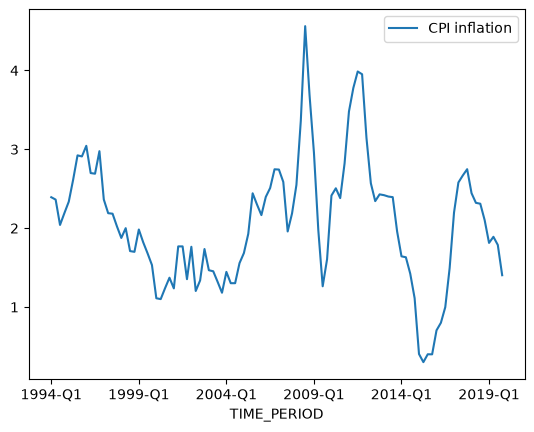

In [188]:
cpi_yoy['United Kingdom'].plot(label = 'CPI inflation')
plt.legend()
plt.show()

The CPI inflation in the UK saw a relatively stable outlook before the 2008 financial crisis, when it first rose to the highest in the given time period, then dipped, and continued to exhibit a much more volatile behaviour 

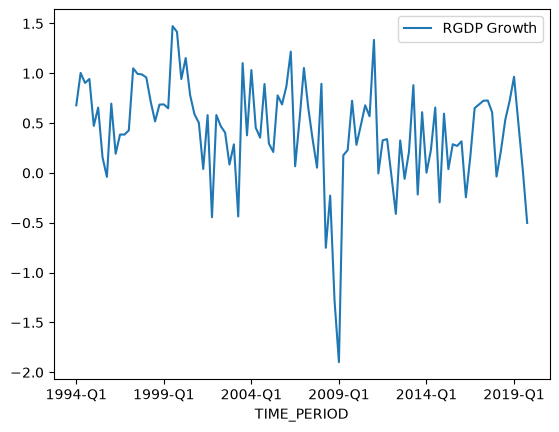

In [189]:
rgdp['France'].plot(label = 'RGDP Growth')
plt.legend()
plt.show()

RGDP growth in France was mostly moderately positive up to 2008, dipping into negatives two times in the early 2000s, and then saw a fall by 2% in 2009 Q1, exhibiting a a more volatile outlook after that, but still averaging at around 0.25%

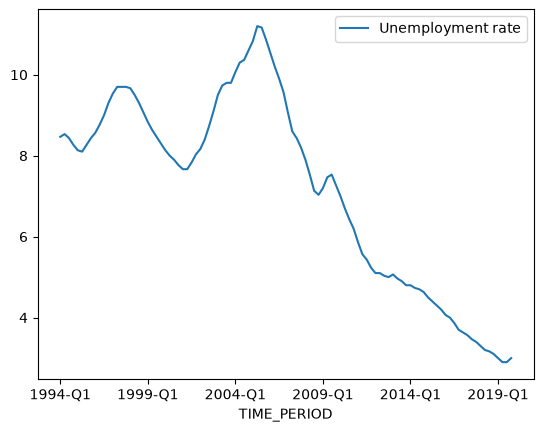

In [191]:
unemployment['Germany'].plot(label = 'Unemployment rate')
plt.legend()
plt.show()